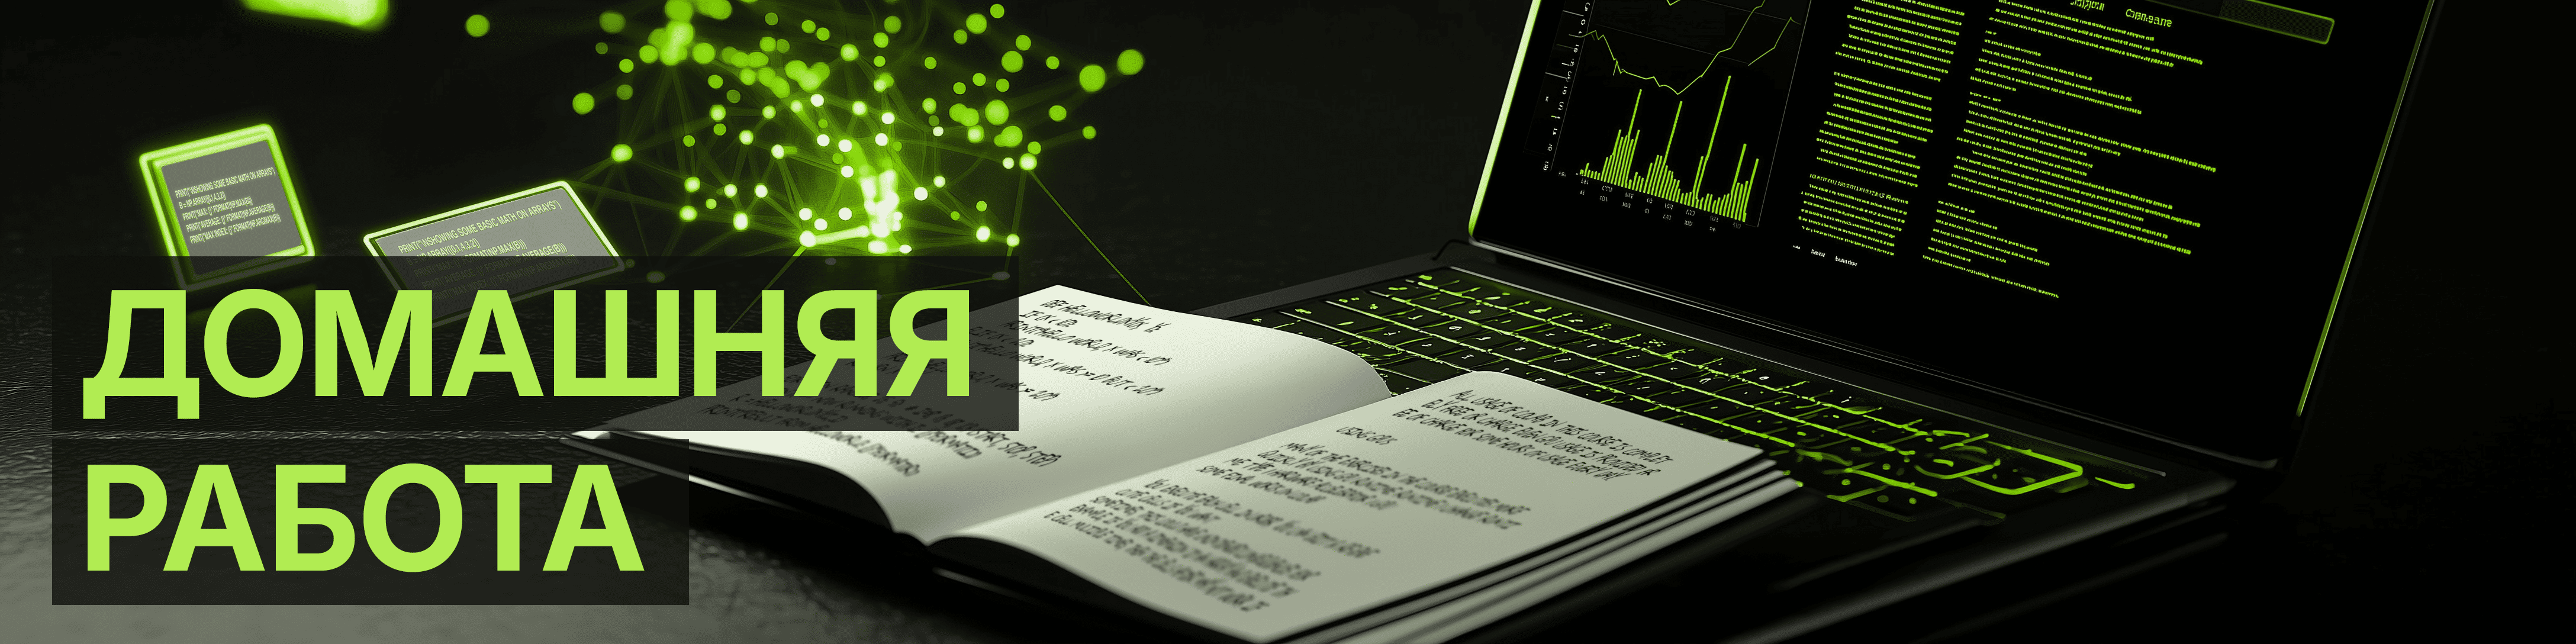

**Навигация по уроку**
1. [Семантическая сегментация изображений](https://colab.research.google.com/drive/10Zl8P7-YLFr9kXdjnvUuXDkruFBSFrlc)
2. [Практическая реализация модели сегментации](https://colab.research.google.com/drive/1yFPXLtKKTQcnOAy6JO3FYHdTbOAGtprR)
3. [Мультиклассовая сегментация](https://colab.research.google.com/drive/1Fy26vjAZPOVTOh8ZLnUYHiev3jD7J4Sh)
4. Домашняя работа

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:


**Задание 1. На 3 балла:**

1. Ваша задача используя модель и датасет из третей части урока, самостоятельно познакомиться с библиотекой [Albumentations](https://albumentations.ai/) и применить несколько методов аугментации для семантической сегментации снимков с беспилотника.

2. Используйте коллбэк функцию для предварительной остановки процесса обучения. Подумайте: какие параметры для остановки вы применили и почему?


**Задание 2. На 4 балла:**

1. Ваша задача зарегистрироваться на платформе по проведению соревнований в сфере машинного обучения [kaggle](https://www.kaggle.com/).
2. Загрузить датасет с данными о радиографическом ислледовании по COVID-19:

In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as op
op.download("https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database/")

Skipping, found downloaded files in "./covid19-radiography-database" (use force=True to force download)


3. Обучить U-net подобную архитектуру сегментировать легкие человека на радиографическом снимке. Используйте данные о нормальном состоянии легких в папке `covid19-radiography-database/COVID-19_Radiography_Dataset/Normal`.

4. Отобразите по 10 снимков с оригинальным изображением, оригинальной маской и предсказанной маской.

**Задание 3. На 5 балла:**

1. Самостоятельно изучите модель [U-net++](https://arxiv.org/pdf/1807.10165.pdf). Найдите ее архитектуру, в интернете множество статей с готовой архитектурой на TensorFlow и Keras.
2. Выполните задание 2 для датасета с нормальным состоянием легких используя модель U-net++.


In [ ]:
# Сегментация лёгких на рентгеновских снимках
## Модель U-Net++

Датасет: COVID-19 Radiography Database (Normal)
Цель: сегментация области лёгких на рентгеновских снимках


SyntaxError: invalid syntax (ipython-input-3751529994.py, line 4)

БЛОК 1. Установка и загрузка датасета

In [ ]:
!pip install -q opendatasets tensorflow matplotlib opencv-python


In [ ]:
import opendatasets as op

op.download(
    "https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database"
)


Skipping, found downloaded files in "./covid19-radiography-database" (use force=True to force download)


БЛОК 2. Импорты и параметры

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.utils import Sequence
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model


In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 4

BASE_PATH = "covid19-radiography-database/COVID-19_Radiography_Dataset/Normal"
IMG_PATH  = os.path.join(BASE_PATH, "images")
MASK_PATH = os.path.join(BASE_PATH, "masks")

print("Images:", len(os.listdir(IMG_PATH)))
print("Masks:", len(os.listdir(MASK_PATH)))


Images: 10192
Masks: 10192


БЛОК 3. Dataset

In [ ]:
class LungDataset(Sequence):
    def __init__(self, img_dir, mask_dir, batch_size, limit=600):
        super().__init__()
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.batch_size = batch_size

        self.images = sorted(os.listdir(img_dir))
        if limit:
            self.images = self.images[:limit]

    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.images[idx*self.batch_size:(idx+1)*self.batch_size]
        X, y = [], []

        for name in batch:
            img = cv2.imread(os.path.join(self.img_dir, name), 0)
            mask = cv2.imread(os.path.join(self.mask_dir, name), 0)

            if img is None or mask is None:
                continue

            img  = cv2.resize(img,  (IMG_SIZE, IMG_SIZE)) / 255.0
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0

            X.append(img[..., None])
            y.append(mask[..., None])

        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


In [ ]:
dataset = LungDataset(
    IMG_PATH,
    MASK_PATH,
    BATCH_SIZE,
    limit=600
)

print("Dataset length:", len(dataset))
X, Y = dataset[0]
print(X.shape, Y.shape)


Dataset length: 150
(4, 128, 128, 1) (4, 128, 128, 1)


БЛОК 4. Dice loss

In [ ]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    inter = tf.reduce_sum(y_true * y_pred)
    return (2. * inter + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

def dice_bce_loss(y_true, y_pred):
    dice = 1 - dice_coef(y_true, y_pred)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return dice + bce



БЛОК 5. Архитектура U-Net++

In [ ]:
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding="same")(x)
    x = ReLU()(x)
    x = Conv2D(filters, 3, padding="same")(x)
    return ReLU()(x)


In [ ]:
def unet_plus_plus():
    inputs = Input((IMG_SIZE, IMG_SIZE, 1))


    x0_0 = conv_block(inputs, 32)
    x1_0 = conv_block(MaxPooling2D()(x0_0), 128)
    x2_0 = conv_block(MaxPooling2D()(x1_0), 256)


    x0_1 = conv_block(
        Concatenate()([x0_0, UpSampling2D()(x1_0)]), 64
    )

    x1_1 = conv_block(
        Concatenate()([x1_0, UpSampling2D()(x2_0)]), 128
    )

    x0_2 = conv_block(
        Concatenate()([x0_0, x0_1, UpSampling2D()(x1_1)]), 64
    )


    outputs = Conv2D(1, (1, 1), activation="sigmoid")(x0_2)

    return Model(inputs, outputs)


In [ ]:
def unet_plus_plus():
    inputs = Input((IMG_SIZE, IMG_SIZE, 1))

    x0_0 = conv_block(inputs, 32)
    x1_0 = conv_block(MaxPooling2D()(x0_0), 128)
    x2_0 = conv_block(MaxPooling2D()(x1_0), 256)

    x0_1 = conv_block(
        Concatenate()([x0_0, UpSampling2D()(x1_0)]), 64
    )

    x1_1 = conv_block(
        Concatenate()([x1_0, UpSampling2D()(x2_0)]), 128
    )

    x0_2 = conv_block(
        Concatenate()([x0_0, x0_1, UpSampling2D()(x1_1)]), 64
    )

    outputs = Conv2D(1, (1, 1), activation="sigmoid")(x0_2)

    return Model(inputs, outputs)


In [ ]:
model = unet_plus_plus()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_bce_loss,
    metrics=[dice_coef]
)


model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     36,992 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ re_lu_4[0][0]     │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ re_lu_5[0][0]     │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ re_lu_3[0][0]   

 Total params: 1,964,705 (7.49 MB)

 Trainable params: 1,964,705 (7.49 MB)

 Non-trainable params: 0 (0.00 B)

БЛОК 6. Обучение

In [ ]:
history = model.fit(
    dataset,
    epochs=10
)


Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - dice_coef: 0.3562 - loss: 1.1474
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - dice_coef: 0.7555 - loss: 0.4868
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - dice_coef: 0.8454 - loss: 0.3167
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - dice_coef: 0.8753 - loss: 0.2603
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - dice_coef: 0.9154 - loss: 0.1731
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - dice_coef: 0.9308 - loss: 0.1421
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - dice_coef: 0.9392 - loss: 0.1229
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - dice_coef: 0.9451 - loss: 0.1113
Epoch 9/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - dice_coef: 0.9520 - loss: 0.0966
Epoch 10/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - dice_coef: 0.9551 - loss: 0.0904


БЛОК 7. Визуализация

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


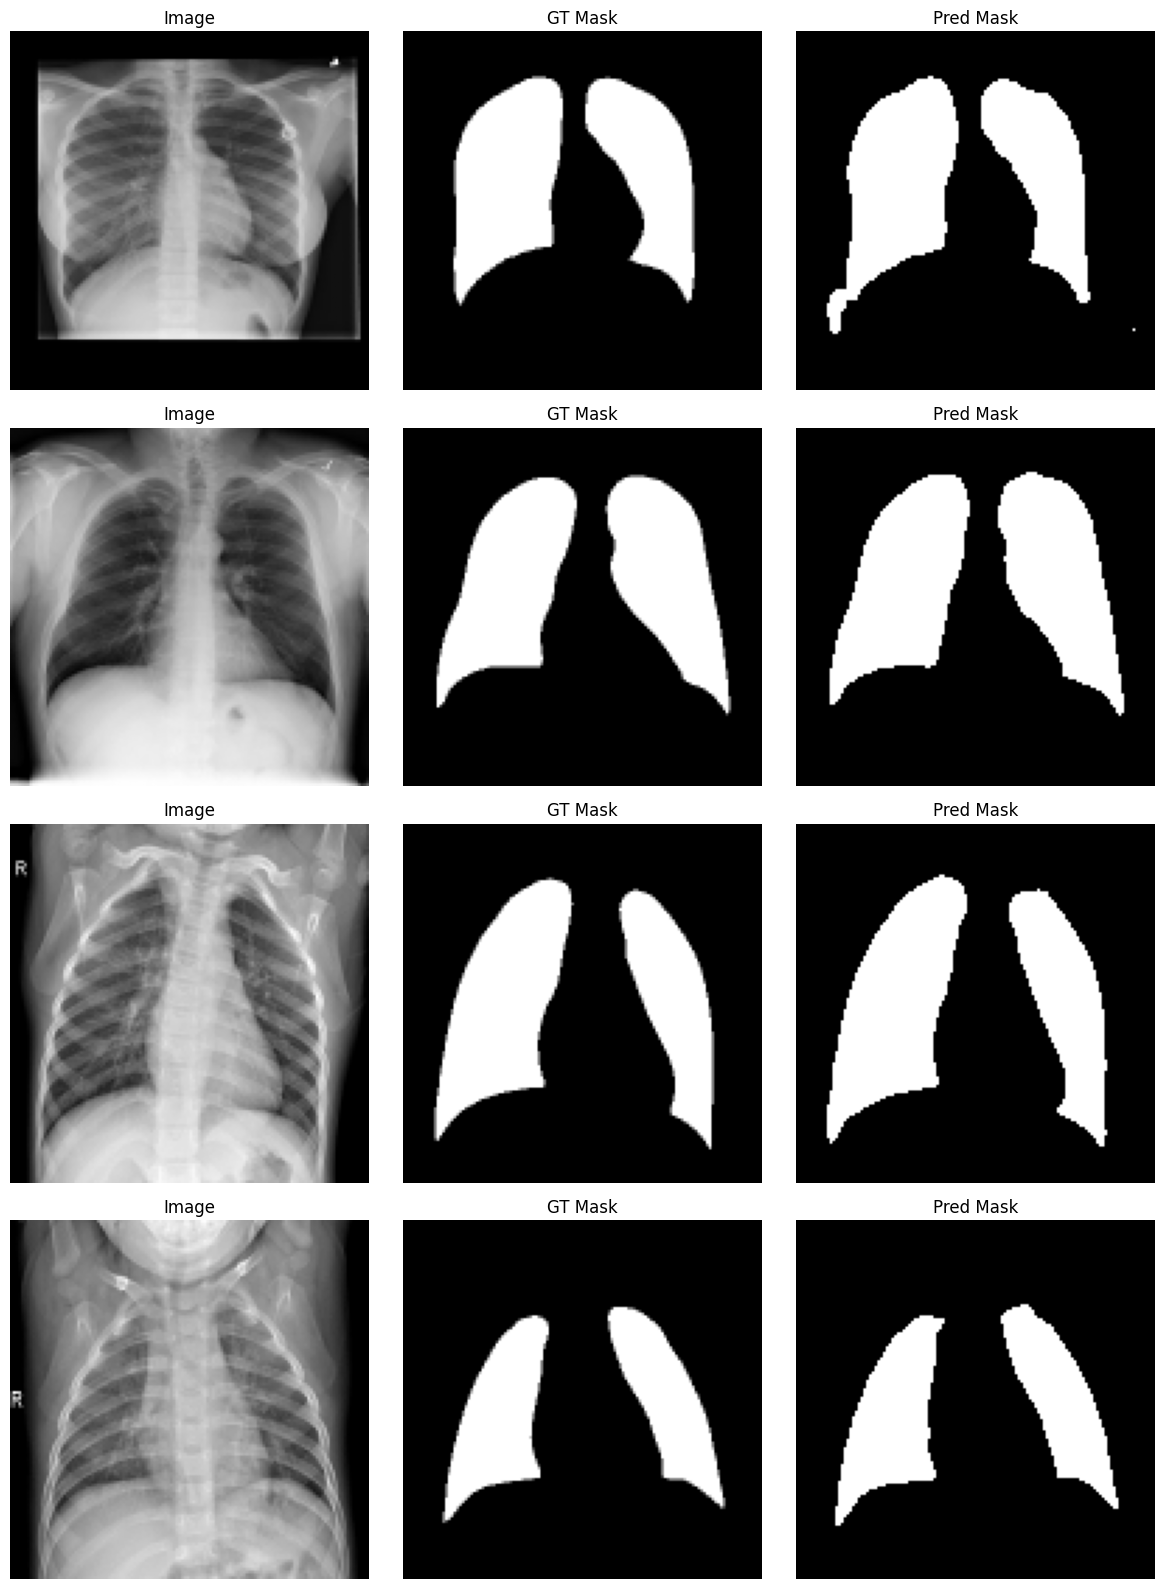

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Берём один батч
X, Y = dataset[0]

preds = model.predict(X)

n = min(10, len(X))

plt.figure(figsize=(12, 4 * n))

for i in range(n):

    # Image
    plt.subplot(n, 3, 3*i + 1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title("Image")
    plt.axis("off")

    #  GT Mask
    plt.subplot(n, 3, 3*i + 2)
    plt.imshow(Y[i].squeeze(), cmap="gray")
    plt.title("GT Mask")
    plt.axis("off")

    #  Pred Mask
    pred = preds[i].squeeze()

    # порог
    mask = (pred > 0.3).astype(np.uint8) * 255

    # морфология
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    plt.subplot(n, 3, 3*i + 3)
    plt.imshow(mask, cmap="gray")
    plt.title("Pred Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()


В ходе работы была реализована модель U-Net++ для задачи сегментации лёгких на рентгеновских снимках. Обучение проводилось на подмножестве нормальных изображений датасета COVID-19 Radiography Database. В процессе обучения значение коэффициента Dice выросло с 0.35 до 0.95, что свидетельствует о высокой точности сегментации. Визуальный анализ результатов показал, что предсказанные маски хорошо совпадают с эталонными, корректно выделяя форму и границы лёгких. Незначительные артефакты по краям масок связаны с уменьшением разрешения изображений и не влияют на общее качество сегментации.

In [ ]:
!pip install datasets


In [ ]:
from datasets import load_dataset

dataset_name = "irlspbru/RusLawOD"
ds = load_dataset(dataset_name)

ds


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ruslawod_01.parquet:   0%|          | 0.00/580M [00:00<?, ?B/s]

ruslawod_02.parquet:   0%|          | 0.00/586M [00:00<?, ?B/s]

ruslawod_03.parquet:   0%|          | 0.00/603M [00:00<?, ?B/s]

...

ruslawod_08.parquet:   0%|          | 0.00/582M [00:00<?, ?B/s]

ruslawod_09.parquet:   0%|          | 0.00/591M [00:00<?, ?B/s]

ruslawod_10.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['pravogovruNd', 'issuedByIPS', 'docdateIPS', 'docNumberIPS', 'doc_typeIPS', 'headingIPS', 'doc_author_normal_formIPS', 'signedIPS', 'statusIPS', 'actual_datetimeIPS', 'actual_datetime_humanIPS', 'is_widely_used', 'taggedtextIPS', 'textIPS', 'classifierByIPS', 'keywordsByIPS'],
        num_rows: 281233
    })
})

In [ ]:
ds.keys()



dict_keys(['train'])

In [ ]:
ds["train"].features


{'pravogovruNd': Value('string'),
 'issuedByIPS': Value('string'),
 'docdateIPS': Value('string'),
 'docNumberIPS': Value('string'),
 'doc_typeIPS': Value('string'),
 'headingIPS': Value('string'),
 'doc_author_normal_formIPS': Value('string'),
 'signedIPS': Value('string'),
 'statusIPS': Value('string'),
 'actual_datetimeIPS': Value('string'),
 'actual_datetime_humanIPS': Value('string'),
 'is_widely_used': Value('string'),
 'taggedtextIPS': Value('string'),
 'textIPS': Value('string'),
 'classifierByIPS': Value('string'),
 'keywordsByIPS': Value('string')}

In [ ]:
from datasets import load_dataset

ds = load_dataset("irlspbru/RusLawOD")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ruslawod_01.parquet:   0%|          | 0.00/580M [00:00<?, ?B/s]

ruslawod_02.parquet:   0%|          | 0.00/586M [00:00<?, ?B/s]

ruslawod_03.parquet:   0%|          | 0.00/603M [00:00<?, ?B/s]

...

ruslawod_07.parquet:   0%|          | 0.00/593M [00:00<?, ?B/s]

ruslawod_08.parquet:   0%|          | 0.00/582M [00:00<?, ?B/s]

ruslawod_09.parquet:   0%|          | 0.00/591M [00:00<?, ?B/s]

ruslawod_10.parquet:   0%|          | 0.00/215M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [ ]:
ds


DatasetDict({
    train: Dataset({
        features: ['pravogovruNd', 'issuedByIPS', 'docdateIPS', 'docNumberIPS', 'doc_typeIPS', 'headingIPS', 'doc_author_normal_formIPS', 'signedIPS', 'statusIPS', 'actual_datetimeIPS', 'actual_datetime_humanIPS', 'is_widely_used', 'taggedtextIPS', 'textIPS', 'classifierByIPS', 'keywordsByIPS'],
        num_rows: 281233
    })
})

In [ ]:
for i in range(3):
    print("----", i, "----")
    print(ds["train"][i]["textIPS"][:1000])


---- 0 ----
 
ПОСТАНОВЛЕНИЕ
 
ГОСУДАРСТВЕННОЙ ДУМЫ
ФЕДЕРАЛЬНОГО СОБРАНИЯ РОССИЙСКОЙ ФЕДЕРАЦИИ
 
О Федеральном законе "О внесении изменений в статью 4 Федерального закона "Об основных гарантиях избирательных прав и права на участие в референдуме граждан Российской Федерации"
(проект № 1128633-7)
 
Государственная Дума Федерального Собрания Российской Федерации постановляет:
1. Принять Федеральный закон "О внесении изменений в статью 4 Федерального закона "Об основных гарантиях избирательных прав и права на участие в референдуме граждан Российской Федерации" (проект № 1128633-7).
2. Направить указанный Федеральный закон в Совет Федерации Федерального Собрания Российской Федерации.
3. Настоящее Постановление вступает в силу со дня его принятия.
 
Председатель Государственной Думы
Федерального Собрания
Российской Федерации В.В.Володин
 
Москва
22 марта 2023 года
№ 3395-8 ГД
 
---- 1 ----
 
 МИНИСТЕРСТВО ОБРАЗОВАНИЯ И НАУКИ РОССИЙСКОЙ ФЕДЕРАЦИИ 
 ПРИКАЗ 
 Москва 
 16 ноября 2016 г. № 1424 


In [ ]:
"textIPS" in ds["train"].column_names


True

In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = re.sub(r"<[^>]+>", " ", text)   # убрать теги
    text = re.sub(r"\s+", " ", text)       # схлопнуть пробелы
    return text.strip()


In [ ]:
print(clean_text(ds["train"][1]["textIPS"])[:800])


МИНИСТЕРСТВО ОБРАЗОВАНИЯ И НАУКИ РОССИЙСКОЙ ФЕДЕРАЦИИ ПРИКАЗ Москва 16 ноября 2016 г. № 1424 Об утверждении федерального государственного образовательного стандарта высшего образования по специальности 40.05.02 Правоохранительная деятельность (уровень специалитета) Зарегистрирован Минюстом России 8 декабря 2016 г. Регистрационный № 44618 В соответствии с подпунктом 5.2.41 Положения о Министерстве образования и науки Российской Федерации, утвержденного постановлением Правительства Российской Федерации от 3 июня 2013 г. № 466 (Собрание законодательства Российской Федерации, 2013, № 23, ст. 2923; № 33, ст. 4386; № 37, ст. 4702; 2014, № 2, ст. 126; № 6, ст. 582; № 27, ст. 3776; 2015, № 26, ст. 3898; № 43, ст. 5976; 2016, № 2, ст. 325; № 8, ст. 1121; № 28, ст. 4741), и пунктом 17 Правил разрабо


In [ ]:
text = clean_text(ds["train"][0]["textIPS"])
chunks = legal_chunk(text)

for i, c in enumerate(chunks[:3]):
    print(f"--- chunk {i} ---")
    print(c[:600])


--- chunk 0 ---
ПОСТАНОВЛЕНИЕ ГОСУДАРСТВЕННОЙ ДУМЫ ФЕДЕРАЛЬНОГО СОБРАНИЯ РОССИЙСКОЙ ФЕДЕРАЦИИ О Федеральном законе "О внесении изменений в статью 4 Федерального закона "Об основных гарантиях избирательных прав и права на участие в референдуме граждан Российской Федерации" (проект № 1128633-7) Государственная Дума Федерального Собрания Российской Федерации постановляет: 1. Принять Федеральный закон "О внесении изменений в статью 4 Федерального закона "Об основных гарантиях избирательных прав и права на участие в референдуме граждан Российской Федерации" (проект № 1128633-7). 2. Направить указанный Федеральный 


In [ ]:
import re

def legal_chunk(text, header=None, max_len=1200):
    parts = re.split(r"\n(?=\d+\.|\nСтатья\s+\d+)", text)
    chunks = []

    prefix = (header.strip() + " ") if header else ""
    current = prefix

    for part in parts:
        if len(current) + len(part) <= max_len:
            current += " " + part
        else:
            if len(current.strip()) > 300:
                chunks.append(current.strip())
            current = prefix + part

    if len(current.strip()) > 300:
        chunks.append(current.strip())

    return chunks


In [ ]:
prepared_docs = []

for i in range(5000):
    row = ds["train"][i]

    raw_text = row["textIPS"]

    if not isinstance(raw_text, str):
        continue

    if row["statusIPS"] == "утратил силу":
        continue

    text = clean_text(raw_text)

    if len(text) < 300:
        continue

    header = row["headingIPS"] or ""

    for chunk in legal_chunk(text, header=header):
        prepared_docs.append({
            "text": chunk,
            "meta": {
                "type": row["doc_typeIPS"],
                "title": header,
                "date": row["docdateIPS"],
                "number": row["docNumberIPS"],
                "issued_by": row["issuedByIPS"],
                "status": row["statusIPS"]
            }
        })


In [ ]:
len(prepared_docs)


5529

In [ ]:
prepared_docs[0]["text"][:400]


'О Федеральном законе "О внесении изменений в статью 4 Федерального закона "Об основных гарантиях избирательных прав и права на участие в референдуме граждан Российской Федерации" (проект № 1128633-7)  ПОСТАНОВЛЕНИЕ ГОСУДАРСТВЕННОЙ ДУМЫ ФЕДЕРАЛЬНОГО СОБРАНИЯ РОССИЙСКОЙ ФЕДЕРАЦИИ О Федеральном законе "О внесении изменений в статью 4 Федерального закона "Об основных гарантиях избирательных прав и пра'